# Difference-in-Difference (DiD)

- 출처
    - 실무로 통하는 인과추론 with 파이썬

In [1]:
!pip install toolz

In [2]:
!pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl (1.6 MB)


In [3]:
!pip install doubleml

  Using cached doubleml-0.10.1-py3-none-any.whl.metadata (8.3 kB)
Using cached doubleml-0.10.1-py3-none-any.whl (471 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 8.9 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
kats 0.2.0 requires ax-platform==0.2.4, which is not installed.
kats 0.2.0 requires deprecated>=1.2.12, which is not installed.
kats 0.2.0 requires fbprophet==0.7.1, which is not installed.
kats 0.2.0 requires gpytorch, which is not installed.
kats 0.2.0 requires holidays>=0.10.2, which is not installed.
kats 0.2.0 requires LunarCalendar>=0.0.9, which is not installed.
kats 0.2.0 requires parameterized>=0.8.1, which is not installed.
kats 0.2.0 requires pymannkendall>=1.4.1, which is not installed.
kats 0.2.0 requires pystan==2.19.1.1, which is not installed.
kats 0.2.0 requires pytest-mpl>=0.12, which is not in

## 가상환경 정보

In [4]:
!python --version

Python 3.9.21


In [5]:
!pip freeze

appdirs @ file:///home/conda/feedstock_root/build_artifacts/appdirs_1733753955715/work
appnope @ file:///home/conda/feedstock_root/build_artifacts/appnope_1733332318622/work
asttokens @ file:///home/conda/feedstock_root/build_artifacts/asttokens_1733250440834/work
attrs==25.3.0
beautifulsoup4 @ file:///home/conda/feedstock_root/build_artifacts/beautifulsoup4_1738740337718/work
Brotli @ file:///Users/runner/miniforge3/conda-bld/brotli-split_1725267563793/work
Cartopy==0.23.0
certifi @ file:///home/conda/feedstock_root/build_artifacts/certifi_1739515848642/work/certifi
cffi @ file:///Users/runner/miniforge3/conda-bld/cffi_1725560622100/work
charset-normalizer @ file:///home/conda/feedstock_root/build_artifacts/charset-normalizer_1735929714516/work
colorama @ file:///home/conda/feedstock_root/build_artifacts/colorama_1733218098505/work
comm @ file:///home/conda/feedstock_root/build_artifacts/comm_1733502965406/work
contourpy @ file:///Users/runner/miniforge3/conda-bld/contourpy_1729602398

## 패키지 불러오기

In [6]:

import warnings, logging
import numpy as np
import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import norm

from lightgbm import LGBMRegressor, LGBMClassifier
from doubleml import DoubleMLData, DoubleMLDID




from toolz import *

import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
from cycler import cycler
import matplotlib.ticker as plticker


color = ['0.0', '0.4', '0.8']
default_cycler = cycler(color=color)
linestyle = ['-', '--', ':', '-.']
marker = ['o', 'v', 'd', 'p']

plt.rc('axes', prop_cycle=default_cycler)



warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.category').setLevel(logging.ERROR)

##  데이터 불러오기

In [7]:


mkt_data = (pd.read_csv("../data/matheus_data/short_offline_mkt_south.csv")
           .astype({"date":"datetime64[ns]"}))




mkt_data.head()

,date,city,region,treated,tau,downloads,post
0,2021-05-01,5,S,0,0.0,51.0,0
1,2021-05-02,5,S,0,0.0,51.0,0
2,2021-05-03,5,S,0,0.0,51.0,0
3,2021-05-04,5,S,0,0.0,50.0,0
4,2021-05-05,5,S,0,0.0,49.0,0


처치 개입 전후 기간 확인

In [8]:
(mkt_data
 .assign(w = lambda d: d["treated"]*d["post"])
 .groupby(["w"])
 .agg({"date":[min, max]}))

date           
         min        max
w                      
0 2021-05-01 2021-06-01
1 2021-05-15 2021-06-01

In [9]:
did_data = (mkt_data
            .groupby(["treated", "post"])
            .agg({"downloads":"mean", "date": "min"}))

did_data

downloads       date
treated post                      
0       0     50.335034 2021-05-01
        1     50.556878 2021-05-15
1       0     50.944444 2021-05-01
        1     51.858025 2021-05-15

## DiD 
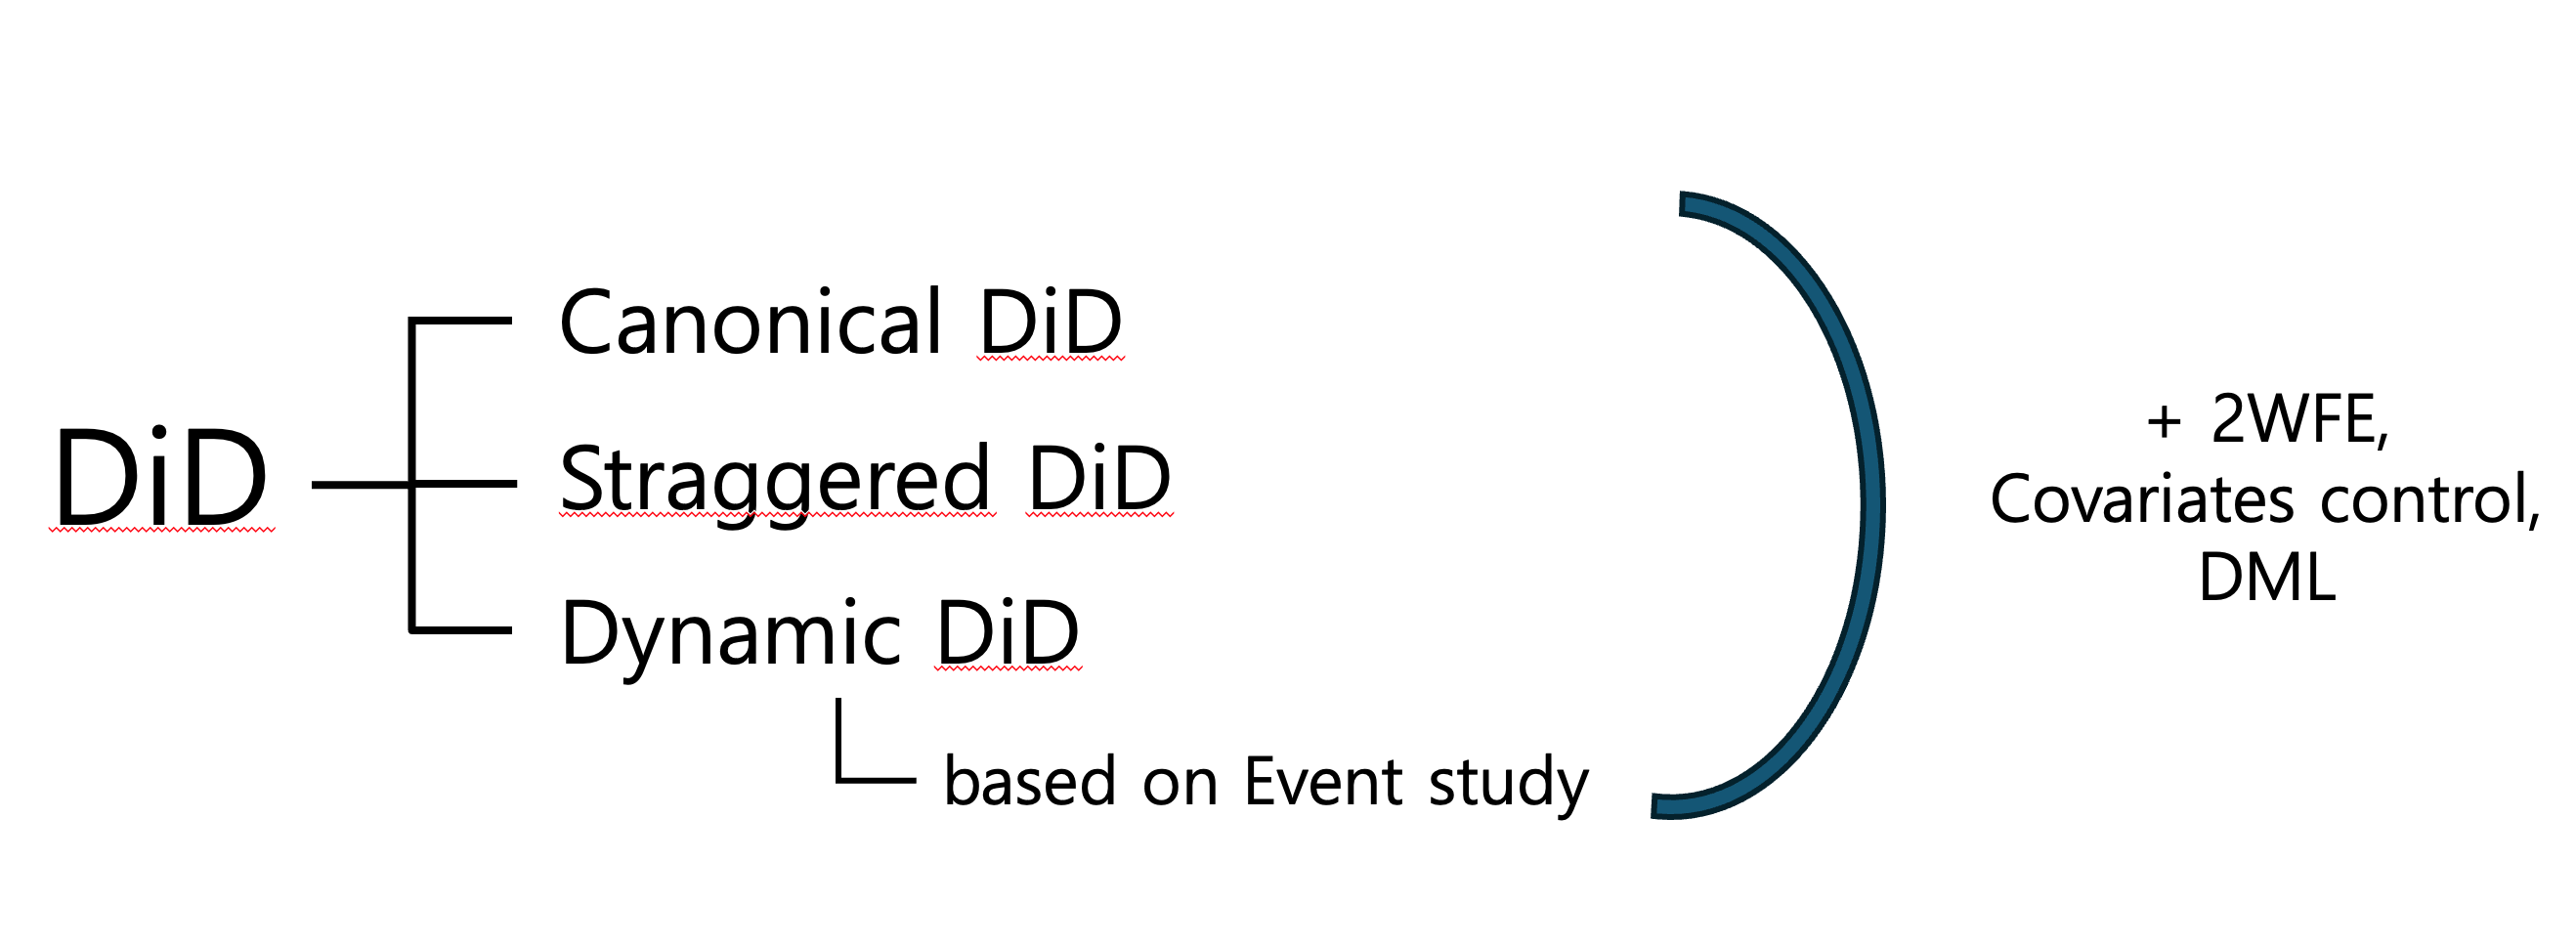

## 이중 차분법에 대한 접근법 3가지
1. 평균을 이용한 이중 차분법 (Basic DID 2x2)
2. 시간에 따른 결과 변화 값을 이용한 이중차분법
3. 선형회귀를 이용한 이중차분법(Regression DID) 
   - 3.1 데이터 집계 방식
   - 3.2 Basic DiD
   - 3.3 TWFE DID
   - 3.4 DID with covariates (Control DID: 추가 통제 포함)
   - 3.4.1 DoubleML 


### 1. 평균을 이용한 이중 차분법(Basic DID 2x2)



- 처치 그룹/대조 그룹, 처치 전/후 두 시점의 평균 차이의 차이를 직접 계산하는 방법입니다.
- 가장 직관적이고 기본적인 DiD 개념입니다.
- 다중 시점 데이터나 추가적인 교란 변수를 통제하기 어렵습니다. 통계적 유의성 검정이 별도의 과정이 필요합니다.
- 복잡한 데이터와 더 견고한 통계적 추론을 위해 회귀 분석 기반의 접근법이 필요하게 됩니다.

In [10]:
y0_est = (did_data.loc[1].loc[0, "downloads"] # treated baseline
          # control evolution
          + did_data.loc[0].diff().loc[1, "downloads"]) 

att = did_data.loc[1].loc[1, "downloads"] - y0_est
att

0.6917359536407233

In [11]:
mkt_data.query("post==1").query("treated==1")["tau"].mean()

0.7660316402518457

### 2. 시간에 따른 결과 변화 값을 이용한 이중차분법

- 각 개별 단위(예: 도시)의 처치 전후 결과값 평균의 차이($\Delta Y_i$​)를 직접 계산하여, 이 단위별 변화 값($\Delta Y_i$​)을 사용하는 방법입니다.
- DiD의 '변화 속의 변화'를 직관적으로 이해하고, 단위의 시간 불변 특성을 자동 통제합니다.
- Basic DiD와 동일한 결과를 회귀식으로 도출하며 통계적 유의성 확인이 용이합니다.
- 더 복잡한 DiD(TWFE)로 나아가기 위한 개념적 디딤돌입니다.
- 두 시점 외 복잡한 다중 시점 데이터 처리나 시간에 따라 변하는 외부 교란 요인을 직접 통제하기 어렵습니다.


In [12]:
pre = mkt_data.query("post==0").groupby("city")["downloads"].mean()
post = mkt_data.query("post==1").groupby("city")["downloads"].mean()

delta_y = ((post - pre)
           .rename("delta_y")
           .to_frame()
           # add the treatment dummy
           .join(mkt_data.groupby("city")["treated"].max()))

delta_y.tail()

,delta_y,treated
city,,
192,0.555556,0
193,0.166667,0
195,0.420635,0
196,0.119048,0
197,1.595238,1


In [13]:
(delta_y.query("treated==1")["delta_y"].mean() 
 - delta_y.query("treated==0")["delta_y"].mean())

0.6917359536407155

DID 모형에 따른 실험군과 대조군의 추세 및 실험군의 가상적(반사실적) 추세

In [14]:
did_data

downloads       date
treated post                      
0       0     50.335034 2021-05-01
        1     50.556878 2021-05-15
1       0     50.944444 2021-05-01
        1     51.858025 2021-05-15

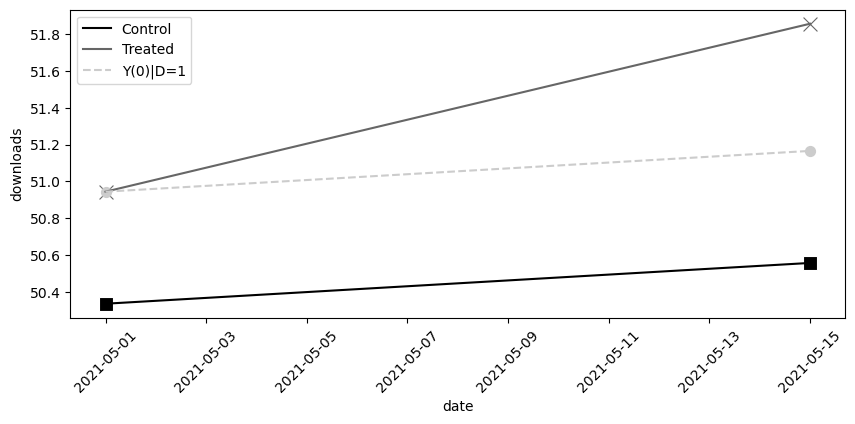

In [15]:
did_plt = did_data.reset_index()


plt.figure(figsize=(10,4))

sns.scatterplot(data=did_plt.query("treated==0"), x="date", y="downloads", s=100, color="C0", marker="s")
sns.lineplot(data=did_plt.query("treated==0"), x="date", y="downloads", label="Control", color="C0")

sns.scatterplot(data=did_plt.query("treated==1"), x="date", y="downloads", s=100, color="C1", marker="x")
sns.lineplot(data=did_plt.query("treated==1"), x="date", y="downloads", label="Treated", color="C1",)

plt.plot(did_data.loc[1, "date"], [did_data.loc[1, "downloads"][0], y0_est], color="C2", linestyle="dashed", label="Y(0)|D=1")
plt.scatter(did_data.loc[1, "date"], [did_data.loc[1, "downloads"][0], y0_est], color="C2", s=50)

plt.xticks(rotation = 45)
plt.legend()


### 3. 선형회귀를 이용한 이중차분법(Regression DID)

DiD를 회귀식으로 표현하여 통계적 엄밀성을 확보하는 방법입니다. 데이터 집계 방식에 따라 두 가지 접근법이 있습니다.

먼저 Canonical DID를 추정할 때 두 가지 데이터 집계 방식이 사용될 수 있습니다. 
1. 개입 전/후 기간을 하나의 블록으로 집계한 데이터
2. 각 개별 시점의 데이터를 그대로 사용

핵심은 어떤 데이터를 수집하더라도 분석에 사용할 최종 데이터 형태가 블록디자인을 따르면 된다는 것입니다.

- 블록 디자인이란?
   - 동일한 시점에 처치를 받는 단위들을 하나의 블록으로 묶고 그 블록과 처치를 받지 않는 블록(control)을 비교하는 구조
  

#### 3. 1 데이터 집계 방식 1: 개입 전/후 기간을 하나의 블록으로 집계한 데이터 (data set : did data)

- 그룹(처치/대조)별로 처치 전 평균과 처치 후 평균을 구한 후, 이를 바탕으로 회귀 모델을 만드는 방식입니다.
- Basic DID (2x2)와 동일한 결과값을 얻으면서 통계적 유의성을 쉽게 확인할 수 있습니다.
- 다만,개별 관측치 수준의 정보 손실이 있고, 다중 시점의 미시 데이터를 직접 활용하지 못합니다.

In [16]:
did_data = (mkt_data
            .groupby(["city", "post"])
            .agg({"downloads":"mean", "date": "min", "treated": "max"})
            .reset_index())

did_data.head()

,city,post,downloads,date,treated
0,5,0,50.642857,2021-05-01,0
1,5,1,50.166667,2021-05-15,0
2,15,0,49.142857,2021-05-01,0
3,15,1,49.166667,2021-05-15,0
4,20,0,48.785714,2021-05-01,0


 `statsmodels`와 `pyfixest`

DID 분석을 회귀 모형으로 구현할 때,
- **statsmodels (smf)** 은 파이썬에서 가장 널리 쓰이는 범용 회귀 패키지라 기본 구현을 설명하기에 적합합니다.  
- 그러나 DID는 본질적으로 **패널 데이터 + 고정효과(FE) + 클러스터 표준오차**가 중요합니다.  
  이를 편리하게 지원하는 패키지가 바로 **pyfixest**입니다.

따라서 
- statsmodels로는 DID의 기본 원리를 쉽게 보여줄 수 있고,  
- pyfixest로는 실제 실증연구에서 사용하는 **FE-DID, TWFE, robust SE**를 더 직관적으로 구현할 수 있습니다.

In [17]:


smf.ols(
    'downloads ~ treated*post', data=did_data
).fit().params["treated:post"]

0.6917359536407282

#### 3. 1 데이터 집계 방식 2: 각 개별 시점의 데이터를 그대로 사용 (data set : mkt data)
- DID를 추정할때 처치 전후로 각 값들을 그룹화하여 하지 않고 각 시점의 데이터를 모두 활용하는 방법입니다.
- 데이터 집계 방식 1보다 훨씬 강력하며, 단위 고정 효과와 시간 고정 효과를 포함할 수 있는 기반이 됩니다. 
- 또, 데이터 집계 방식 1과 달리 개별 관측치 정보를 최대한 활용합니다. 또한 사전 평행 추세를 검정할 수 있다는 장점이 있습니다.
- 다만, 여전히 시간에 따라 변하는 관측되지 않은 교란 요인을 완전히 제거할 수는 없습니다.


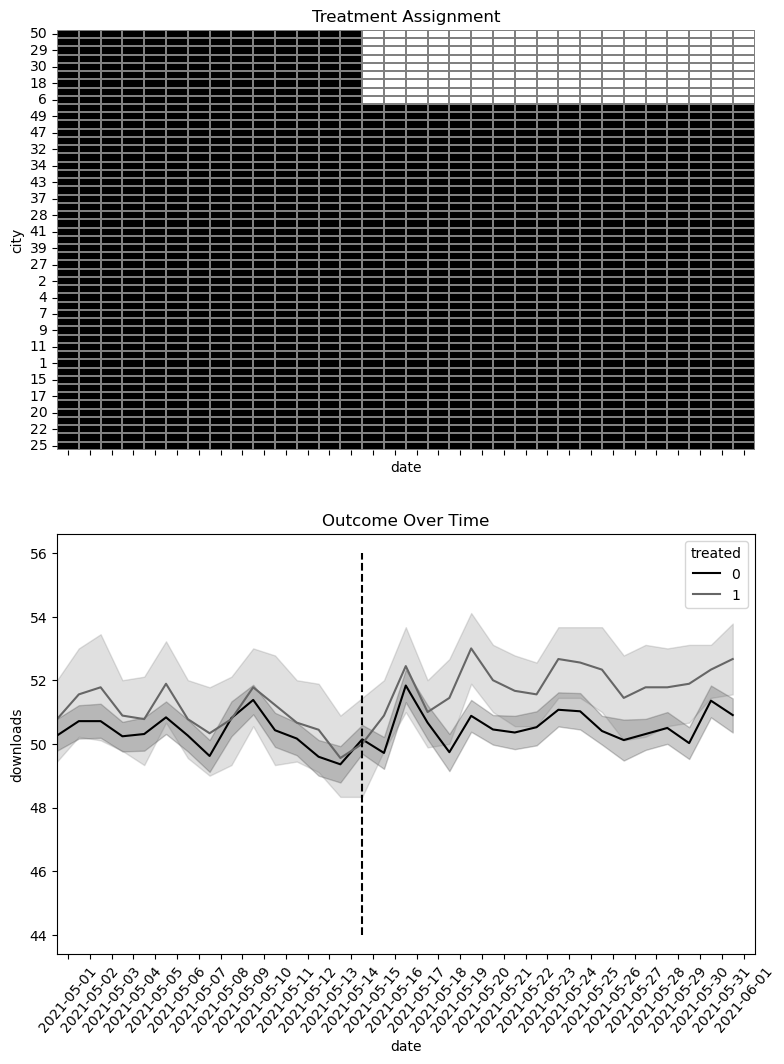

In [18]:


fig, (ax1, ax2) = plt.subplots(2,1, figsize=(9, 12), sharex=True)

heat_plt = (mkt_data
            .assign(treated=lambda d: d.groupby("city")["treated"].transform(max))            
            .astype({"date":"str"})
            .assign(treated=mkt_data["treated"]*mkt_data["post"])
            .pivot(index="city", columns="date", values="treated")
            .reset_index()
            .sort_values(max(mkt_data["date"].astype(str)), ascending=False)
            .reset_index()
            .drop(columns=["city"])
            .rename(columns={"index":"city"})
            .set_index("city"))


sns.heatmap(heat_plt, cmap="gray", linewidths=0.01, linecolor="0.5", ax=ax1, cbar=False)

ax1.set_title("Treatment Assignment")


sns.lineplot(data=mkt_data.astype({"date":"str"}),
             x="date", y="downloads", hue="treated", ax=ax2)

loc = plticker.MultipleLocator(base=2.0)
# ax2.xaxis.set_major_locator(loc)
ax2.vlines("2021-05-15", mkt_data["downloads"].min(), mkt_data["downloads"].max(), color="black", ls="dashed", label="Interv.")
ax2.set_title("Outcome Over Time")

plt.xticks(rotation = 50);

In [19]:
mkt_data

,date,city,region,treated,tau,downloads,post
0,2021-05-01,5,S,0,0.000000,51.0,0
1,2021-05-02,5,S,0,0.000000,51.0,0
2,2021-05-03,5,S,0,0.000000,51.0,0
3,2021-05-04,5,S,0,0.000000,50.0,0
4,2021-05-05,5,S,0,0.000000,49.0,0
...,...,...,...,...,...,...,...
1627,2021-05-28,197,S,1,1.771233,53.0,1
1628,2021-05-29,197,S,1,1.771233,52.0,1
1629,2021-05-30,197,S,1,1.771233,54.0,1
1630,2021-05-31,197,S,1,1.771233,53.0,1




#### 3.2 Basic DID


- 가장 기본적인 회귀 DiD 모델이며, DiD 효과($\beta$)와 함께 각 그룹의 처치 전후 베이스라인 차이 등을 동시에 추정합니다. 
- 통계적 추론(표준 오차, p-값)을 쉽게 제공합니다.
- DiD 효과를 통계적으로 더 견고하게 추정하며, 이후 TWFE DiD 등 더 발전된 모델로 확장하기 위한 직접적인 기반이 됩니다.
- 아직 단위/시간 고정 효과를 명시적으로 통제하지 않으므로, 관측되지 않은 시간에 따른 교란 요인에 의한 편향 가능성이 있습니다.

$$Y_{it} = \beta_0 + \beta_1 D_i + \beta_2 Post_t + \beta_3 D_i Post_t + e_{it}$$

In [20]:
m = smf.ols('downloads ~ treated*post', data=mkt_data).fit()

m.params["treated:post"]

0.6917359536406944

##### 추론

1. 기준 표준 오차 (Homoskedastic Standard Error)

- 오차가 독립적이며 동일 분산을 가진다고 가정합니다.
- 다만 동일 단위 내 관측치 간 상관관계를 무시하여, 표준 오차가 과소평가(실제보다 작게)될 수 있습니다.
- 이로 인해 유의하지 않은 결과도 유의하다고 잘못 판단할 위험이 있습니다.



2. 군집 표준 오차 (Clustered Standard Error)

- 특정 군집(예: city_id) 내에서는 오차 상관관계를 허용하지만, 군집 간에는 독립적이라고 가정합니다. 이분산성에도 강건합니다.
- 패널 데이터의 군집 내 상관관계를 반영하여, 보통 기준 표준 오차보다 더 크게(보수적으로) 추정됩니다.
- 기준 표준 오차의 과소평가 문제를 해결하여, 통계적 유의성 판단의 신뢰성을 높여줍니다. DiD 분석 시 권장됩니다.

1. 기존 표준 오차 기반    

In [21]:
m = smf.ols(
    'downloads ~ treated*post', data=mkt_data
).fit()
print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536406944


0    0.213969
1    1.169503
Name: treated:post, dtype: float64

2. 군집 기반 표준 오차 기반

In [22]:
m = smf.ols(
    'downloads ~ treated*post', data=mkt_data
).fit(cov_type='cluster', cov_kwds={'groups': mkt_data['city']})

print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536406944


0    0.305820
1    1.077652
Name: treated:post, dtype: float64

#### 3.3 2WFE did 

- 데이터 집계 방식 2의 회귀 모델에 단위 고정 효과($\alpha_i$​)와 시간 고정 효과($\gamma_t$​)를 동시에 추가하여 분석하는 방법입니다.
- 단위별 고유 특성(시간 불변)과 모든 단위에 공통된 시간 트렌드를 통제하여 교란 요인을 더 효과적으로 제거합니다.
- 내생성 문제를 완화하고, 다중 시점 데이터를 유연하게 처리할 수 있습니다.
- 시간에 따라 변하는 관측되지 않은 교란 요인이나, 처치 효과가 이질적인 경우(heterogeneous effects) 편향될 수 있습니다.


$$Y_{it} = \tau W_{it} + \alpha_i + \gamma_t + e_{it} \text{  ,where  } W_{it} = D_iPost_t$$



In [23]:
m = smf.ols('downloads ~ treated:post + C(city) + C(date)',
            data=mkt_data).fit()

coef=m.params["treated:post"]

print("DID estimate:", coef)

DID estimate: 0.6917359536407054


##### 데이터 집계 방식에 따른 추론 비교

 1. 집계 방식 1: 단순한 2x2 테이블의 회귀 버전이며, 고정 효과를 적용하기 어렵습니다.
 2. 집계 방식 2: 패널 데이터의 장점을 활용할 수 있는 표준적인 접근법입니다.


1-1 집계방식 1: 기존 표준 오차 기반

In [24]:
m = smf.ols('downloads ~ treated:post + C(city) + C(date)',
            data=did_data).fit()

print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536407496


0    0.409916
1    0.973556
Name: treated:post, dtype: float64

1-2 집계방식 1:군집 표준 오차 기반

In [25]:
m = smf.ols(
    'downloads ~ treated:post + C(city) + C(date)', data=did_data
).fit(cov_type='cluster', cov_kwds={'groups': did_data['city']})

print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536407496


0    0.138188
1    1.245284
Name: treated:post, dtype: float64

2-1 집계방식 2: 기존 표준오차 기반

In [26]:
m = smf.ols('downloads ~ treated:post + C(city) + C(date)',
            data=mkt_data).fit()

print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536407054


0    0.478014
1    0.905457
Name: treated:post, dtype: float64

2-2 집계방식 2: 군집 표준 오차 기반

In [27]:
m = smf.ols(
    'downloads ~ treated:post + C(city) + C(date)', data=mkt_data
).fit(cov_type='cluster', cov_kwds={'groups': mkt_data['city']})

print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536407054


0    0.296101
1    1.087370
Name: treated:post, dtype: float64

##### 추정된 ATT는 동일한데 왜 데이터 집계 방식에 따라 왜 신뢰구간 추정이 달라지는가? 


\begin{array}{lcc}
\textbf{구분} & \textbf{기존 표준오차 (nonrobust)} & \textbf{군집 표준오차 (cluster-robust)} \\ 
\hline
집계방식 1 (pre/post 평균형) & [0.4099 , 0.9736] & [0.1382 , 1.2453] \\
집계방식 2 (개별 시점형) & [0.5152 , 0.8683] & [0.4693 , 0.9142] \\
\end{array}



두 방식의 신뢰구간이 달라지는 이유는
데이터의 집계 수준이 다르기 때문입니다.

집계형 방식(집계 방식 1)은 정보량이 적고 자유도가 작아 표준오차가 커지기 쉬워 신뢰구간이 넓어질 가능성이 높고,

개별 시점형 방식(집계 방식2)은 더 많은 표본과 변동을 활용하므로 표준오차가 작아져 신뢰구간이 오히려 더 좁게 나올 수 있습니다.




#### 3.4 DID with covariates

TWFE DiD 모델에 시간에 따라 변하는 관측 가능한 공변량($X_{it}$​)을 추가하는 방식입니다.
$$Y_{it} = \alpha_i + \gamma_t + \beta (\text{Treated}_i \times \text{Post}_t) + \delta'X_{it} + \epsilon_{it}$$

- 시간에 따라 그룹 간 다르게 변화하는 관측 가능한 교란 요인을 통제함으로써 평행 추세 가정을 더욱 강화합니다.
- 추정치의 정밀도를 높이고, 관측 가능한 교란 요인으로 인한 편향을 줄입니다.
- 어떤 공변량을 포함할지 신중하게 선택해야 하며, 여전히 관측되지 않은 교란 요인에 의한 편향 가능성은 남아 있습니다.




In [147]:
mkt_data_all = (pd.read_csv("../data/matheus_data/short_offline_mkt_all_regions.csv")
                .astype({"date":"datetime64[ns]"}))

In [148]:
mkt_data_all

,date,city,region,treated,tau,downloads,post
0,2021-05-01,1,W,0,0.0,27.0,0
1,2021-05-02,1,W,0,0.0,28.0,0
2,2021-05-03,1,W,0,0.0,28.0,0
3,2021-05-04,1,W,0,0.0,26.0,0
4,2021-05-05,1,W,0,0.0,28.0,0
...,...,...,...,...,...,...,...
6395,2021-05-28,200,W,0,0.0,35.0,1
6396,2021-05-29,200,W,0,0.0,31.0,1
6397,2021-05-30,200,W,0,0.0,33.0,1
6398,2021-05-31,200,W,0,0.0,32.0,1


(array([18748., 18752., 18756., 18760., 18764., 18768., 18772., 18776.,
        18779.]),
 [Text(18748.0, 0, '2021-05-01'),
  Text(18752.0, 0, '2021-05-05'),
  Text(18756.0, 0, '2021-05-09'),
  Text(18760.0, 0, '2021-05-13'),
  Text(18764.0, 0, '2021-05-17'),
  Text(18768.0, 0, '2021-05-21'),
  Text(18772.0, 0, '2021-05-25'),
  Text(18776.0, 0, '2021-05-29'),
  Text(18779.0, 0, '2021-06-01')])

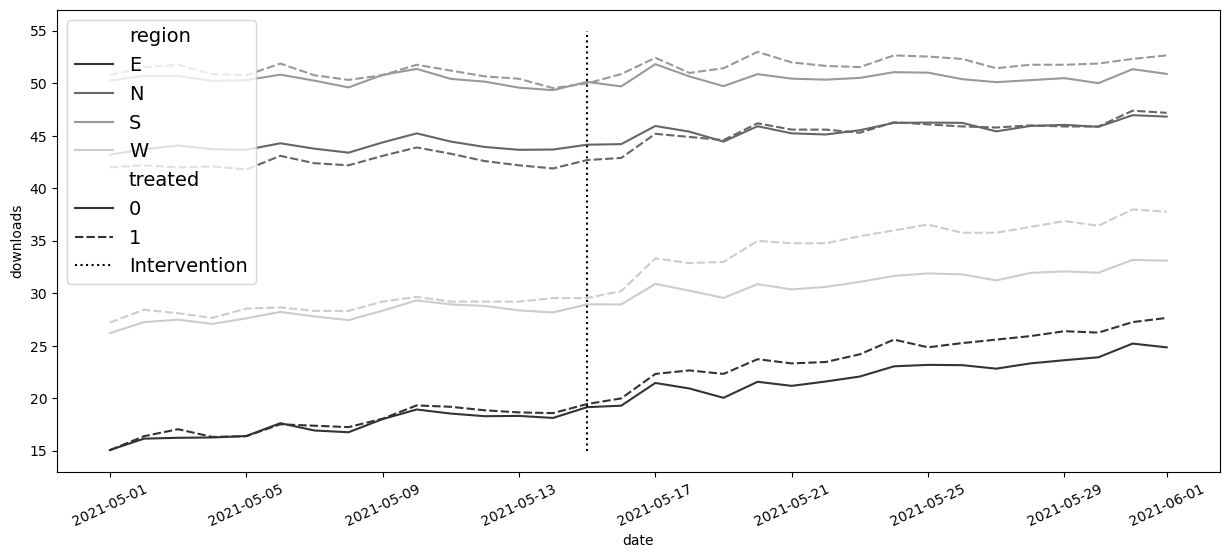

In [29]:
plt.figure(figsize=(15,6))
sns.lineplot(data=mkt_data_all.groupby(["date", "region", "treated"])[["downloads"]].mean().reset_index(),
             x="date", y="downloads", hue="region", style="treated", palette="gray")

plt.vlines(pd.to_datetime("2021-05-15"), 15, 55, ls="dotted", label="Intervention")
plt.legend(fontsize=14)

plt.xticks(rotation=25)

처치 이전 추세의 경우 지역내에서는 평행하지만 지역 간에는 평행하지 않은 것으로 보입니다. 이러한 상황해서 단순히 이원고정효과모델을 적용하면 ATT에 대해 편향된 추정값을 얻게되죠.   

따라서 이 문제를 해결하기 위해선 각 지역별로 서로 다른 추세가 있다는 것을 반드시 고려해야합니다.  

그럼 어떻게 지역별로 서로 다른 추세가 있다는 것을 모델에 반영할 수 있을까요? 바로 모델에 처치전의 공변량(covariates)을 포함하는 것입니다. 

공변량을 모델에 반영하여 ATT추정하는 방법은 대표적으로 2가지 방법이 있습니다.   


1. 각 지역별로 별도의 DID 회귀 모델 적용하고 ATT 가중평균하여 구하기

2. 지역 변수와 처치 후 더미 변수와 상호작용하기


In [30]:
print("True ATT: ", mkt_data_all.query("treated*post==1")["tau"].mean())

True ATT:  1.7208921056102682


##### 1. 각 지역별로 별도의 DID 회귀 모델 적용하고 ATT 가중평균($\hat\theta=\sum_r w_r \widehat{ATT}_r$)하여 구하기

In [31]:
m_saturated = smf.ols('downloads ~ (post*treated)*C(region)',
                      data=mkt_data_all).fit()

atts = m_saturated.params[m_saturated.params.index.str.contains("post:treated")]
atts

post:treated                   1.676808
post:treated:C(region)[T.N]   -0.343667
post:treated:C(region)[T.S]   -0.985072
post:treated:C(region)[T.W]    1.369363
dtype: float64

##### 추정

In [32]:


# (1) region size (가중치 계산)
reg_size = (mkt_data_all.groupby("region").size()
            / len(mkt_data_all["date"].unique()))

# (2) saturated DID 결과 계수
atts = m_saturated.params[m_saturated.params.index.str.contains("post:treated")]
cov = m_saturated.cov_params()  # 분산-공분산 행렬

# (3) base (= region baseline ATT, 보통 첫 지역)
base = atts.iloc[0]

# (4) 선형 조합 벡터 만들기
weights = [reg_size.iloc[0]] + list(reg_size.iloc[1:])
coefs = [base] + list(atts.iloc[1:] + base)

theta = np.dot(weights, coefs) / reg_size.sum()

# (5) 대응되는 선형 조합 벡터 정의 (계수 개수만큼)
# 인덱스 맞추기
att_idx = atts.index
w = np.zeros(len(m_saturated.params))

# baseline
w[m_saturated.params.index.get_loc(att_idx[0])] = reg_size.iloc[0]

# 나머지 region 효과들
for att_name, size in zip(att_idx[1:], reg_size.iloc[1:]):
    w[m_saturated.params.index.get_loc(att_idx[0])] += size   # baseline part
    w[m_saturated.params.index.get_loc(att_name)] += size     # interaction part

# normalize
w = w / reg_size.sum()

# (6) 분산 계산
theta_var = w @ cov @ w
theta_se = np.sqrt(theta_var)

# (7) 신뢰구간
alpha = 0.05
z = norm.ppf(1 - alpha/2)

ci_lower = theta - z * theta_se
ci_upper = theta + z * theta_se

print("Weighted ATT:", theta)
print("95% CI:", (ci_lower, ci_upper))

Weighted ATT: 1.6940400451471702
95% CI: (1.3897593237876387, 1.9983207665067018)


##### 2. 지역변수와 처치 후 더미변수와 상호작용하기

In [ ]:
m = smf.ols('downloads ~ post*(treated + C(region))',
            data=mkt_data_all).fit()

m.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,17.3522,0.101,172.218,0.000,17.155,17.550
C(region)[T.N],26.2770,0.137,191.739,0.000,26.008,26.546
C(region)[T.S],33.0815,0.135,245.772,0.000,32.818,33.345
C(region)[T.W],10.7118,0.135,79.581,0.000,10.448,10.976
post,4.9807,0.134,37.074,0.000,4.717,5.244
post:C(region)[T.N],-3.3458,0.183,-18.310,0.000,-3.704,-2.988
post:C(region)[T.S],-4.9334,0.179,-27.489,0.000,-5.285,-4.582
post:C(region)[T.W],-1.5408,0.179,-8.585,0.000,-1.893,-1.189
treated,0.0503,0.117,0.429,0.668,-0.179,0.280
post:treated,1.6811,0.156,10.758,0.000,1.375,1.987


post:treated에 대한 매개 변수를 ATT로 해석합니다. 

##### 추정

In [34]:
print("ATT:", m.params["post:treated"])
m.conf_int().loc["post:treated"]

ATT: 1.6810982546486941


0    1.374772
1    1.987424
Name: post:treated, dtype: float64

#### 3.5 Staggered DiD
**Staggered DiD: Canonical vs Dynamic View**

| 구분 | Canonical View | Dynamic (Event-study) View |
|:--|:--|:--|
| **핵심 아이디어** | Staggered DiD는 *canonical DiD의 확장형*, 여러 시점과 그룹에 반복 적용된 2×2 DiD 구조 | Staggered DiD를 *event-time 기준*으로 재정렬하여 시점별 효과 $\beta_k$ 추정 (Dynamic DID 형태) |
| **초점** | 평균 처치 효과 (ATT) | 시간에 따른 처치 효과 변화 (dynamic ATT) |
| **처치 시점** | 모든 단위의 개입 시점 동일하거나, 시점별 DiD 반복 | 단위별로 상이한 개입 시점 (staggered adoption) |
| **대표 모형** | $Y_{it} = \alpha_i + \lambda_t + \beta D_{it} + \epsilon_{it}$| $Y_{it} = \alpha_i + \lambda_t + \sum_k \beta_k \cdot 1\{t - G_i = k\} + \epsilon_{it}$|
| **요약** | 구조적으로는 canonical DID의 반복적 적용 | 추정 관점에서는 event-study 기반 Dynamic DID로 해석 가능 


**⇒ Staggered DiD는 canonical DID의 확장형이면서도, event-study 기반 Dynamic DID로 해석될 수 있음.**

In [38]:
mkt_data_cohorts = (pd.read_csv("../data/matheus_data/offline_mkt_staggered.csv")
                    .astype({
                        "date":"datetime64[ns]",
                        "cohort":"datetime64[ns]"}))

mkt_data_cohorts.head()

,date,city,region,cohort,treated,tau,downloads,post
0,2021-05-01,1,W,2021-06-20,1,0.0,27.0,0
1,2021-05-02,1,W,2021-06-20,1,0.0,28.0,0
2,2021-05-03,1,W,2021-06-20,1,0.0,28.0,0
3,2021-05-04,1,W,2021-06-20,1,0.0,26.0,0
4,2021-05-05,1,W,2021-06-20,1,0.0,28.0,0


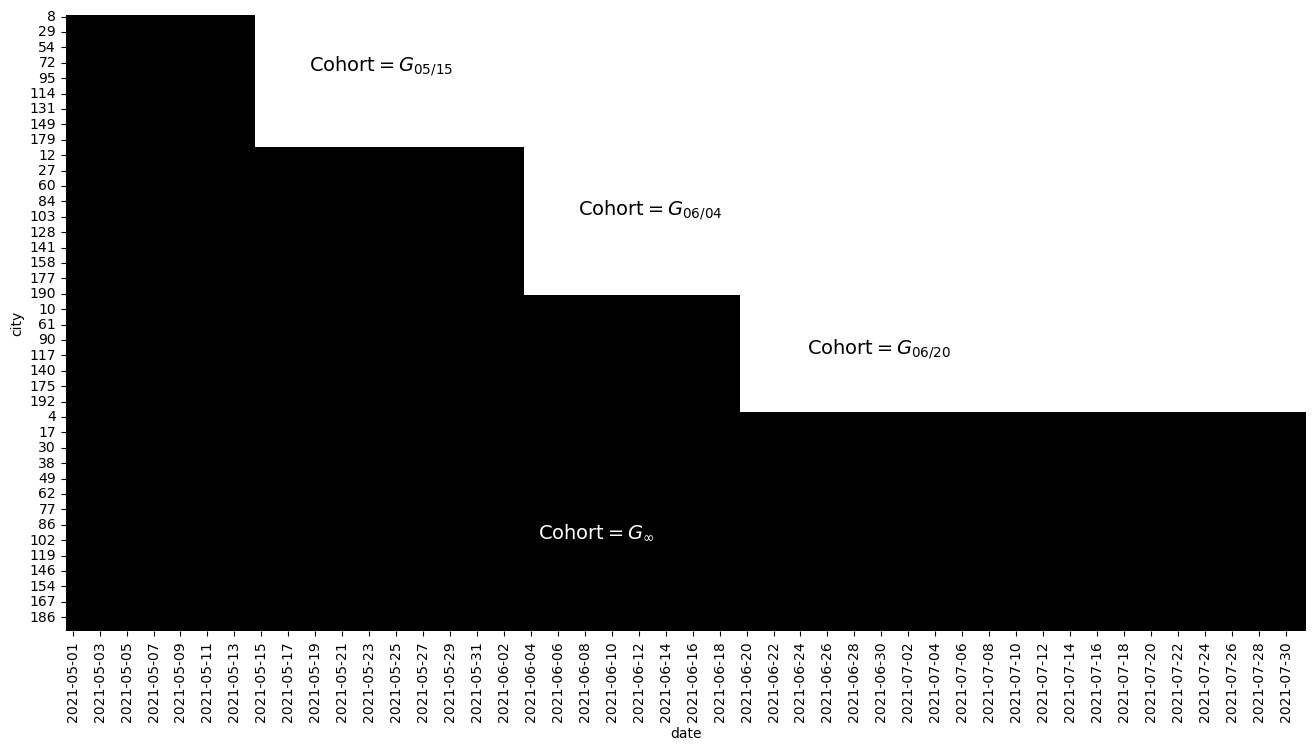

In [40]:
plt_data = (mkt_data_cohorts
            .astype({"date":"str"})
            .assign(treated_post = lambda d: d["treated"]*(d["date"]>=d["cohort"]))
          .pivot(index="city", columns="date", values="treated_post")   
            .reset_index()
            .sort_values(list(sorted(mkt_data_cohorts.query("cohort!='2100-01-01'")["cohort"].astype("str").unique())), ascending=False)
            .reset_index()
            .drop(columns=["city"])
            .rename(columns={"index":"city"})
            .set_index("city"))



plt.figure(figsize=(16,8))

sns.heatmap(plt_data, cmap="gray",cbar=False)
plt.text(18, 18, "Cohort$=G_{05/15}$", size=14)
plt.text(38, 65, "Cohort$=G_{06/04}$", size=14)
plt.text(55, 110, "Cohort$=G_{06/20}$", size=14)
plt.text(35, 170, "Cohort$=G_{\\infty}$", color="white", size=14, weight=3);

In [41]:
mkt_data_cohorts_w = mkt_data_cohorts.query("region=='W'")
mkt_data_cohorts_w.head()

,date,city,region,cohort,treated,tau,downloads,post
0,2021-05-01,1,W,2021-06-20,1,0.0,27.0,0
1,2021-05-02,1,W,2021-06-20,1,0.0,28.0,0
2,2021-05-03,1,W,2021-06-20,1,0.0,28.0,0
3,2021-05-04,1,W,2021-06-20,1,0.0,26.0,0
4,2021-05-05,1,W,2021-06-20,1,0.0,28.0,0


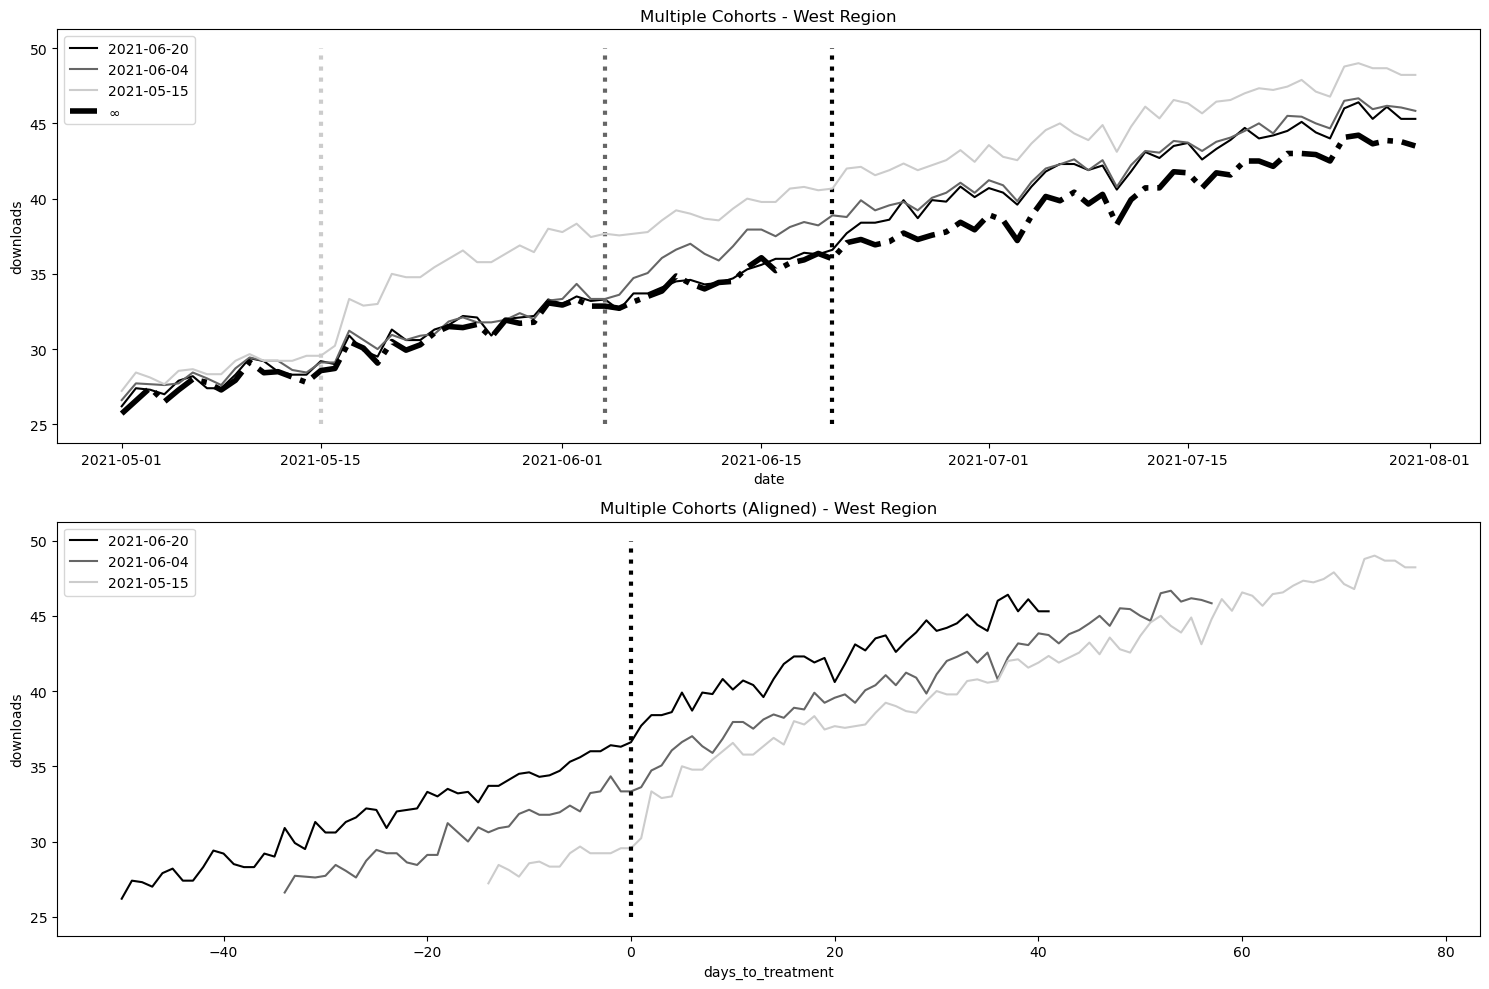

In [42]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

plt_data = (mkt_data_cohorts_w
            .groupby(["date", "cohort"])
            [["downloads"]]
            .mean()
            .reset_index()
)



for color, cohort in zip(["C0", "C1", "C2", "C3"], mkt_data_cohorts_w.query("cohort!='2100-01-01'")["cohort"].unique()):
    df_cohort = plt_data.query("cohort==@cohort")
    sns.lineplot(data=df_cohort, x="date", y="downloads",
                 label=pd.to_datetime(cohort).strftime('%Y-%m-%d'), ax=ax1)
    ax1.vlines(x=cohort, ymin=25, ymax=50, color=color, ls="dotted", lw=3)
    
    
sns.lineplot(data=plt_data.query("cohort=='2100-01-01'"), x="date", y="downloads", label="$\infty$", lw=4, ls="-.", ax=ax1)
        
ax1.legend()
ax1.set_title("Multiple Cohorts - West Region");


plt_data = (mkt_data_cohorts_w
            .assign(days_to_treatment = lambda d: (pd.to_datetime(d["date"])-pd.to_datetime(d["cohort"])).dt.days)
            .groupby(["date", "cohort"])
            [["downloads", "days_to_treatment"]]
            .mean()
            .reset_index()
)


for color, cohort in zip(["C0", "C1", "C2", "C3"], mkt_data_cohorts_w.query("cohort!='2100-01-01'")["cohort"].unique()):
    df_cohort = plt_data.query("cohort==@cohort")
    sns.lineplot(data=df_cohort, x="days_to_treatment", y="downloads",
                 label=pd.to_datetime(cohort).strftime('%Y-%m-%d'), ax=ax2)

ax2.vlines(x=0, ymin=25, ymax=50, color="black", ls="dotted", lw=3)

ax2.set_title("Multiple Cohorts (Aligned) - West Region")
ax2.legend();

plt.tight_layout()

In [47]:
mkt_data_cohorts_w['date'] = mkt_data_cohorts_w['date'].dt.strftime('%Y-%m-%d')
mkt_data_cohorts_w['cohort'] = mkt_data_cohorts_w['cohort'].astype(str)

Number of param.: 510
True Effect:  2.2625252108176266
Pred. Effect:  2.2597661446850026


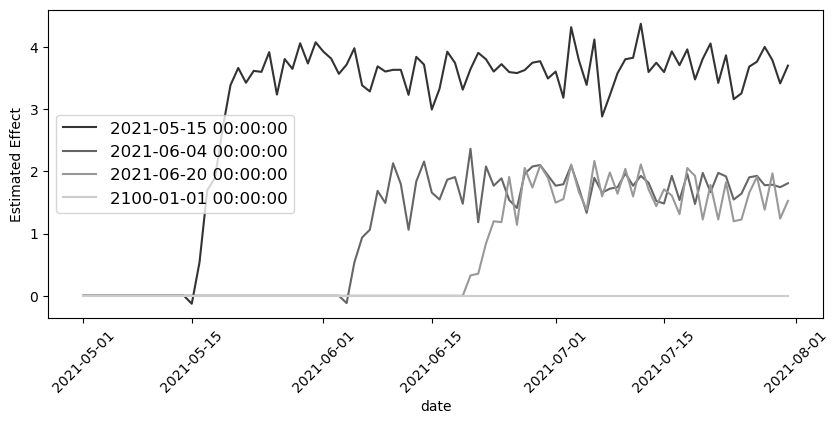

In [48]:
formula = "downloads ~ treated:post:C(cohort):C(date) + C(city) + C(date)"

twfe_model = smf.ols(formula, data=mkt_data_cohorts_w.astype({"date":str, "cohort": str})).fit()

effects = (twfe_model.params[twfe_model.params.index.str.contains("treated")]
           .reset_index()
           .rename(columns={0:"param"})
           .assign(cohort=lambda d: d["index"].str.extract(r'C\(cohort\)\[(.*)\]:'))
           .assign(date=lambda d: d["index"].str.extract(r':C\(date\)\[(.*)\]'))
           .assign(date=lambda d: pd.to_datetime(d["date"]), cohort=lambda d: pd.to_datetime(d["cohort"])))

plt.figure(figsize=(10,4))
sns.lineplot(data=effects, x="date", y="param", hue="cohort", palette="gray")
plt.xticks(rotation=45)
plt.ylabel("Estimated Effect")
plt.legend(fontsize=12)

df_pred = (
    mkt_data_cohorts_w
    .query("post==1 & treated==1")
    .assign(date=lambda d: d['date'].astype(str))  # Convert to string
    .assign(y_hat_0=lambda d: twfe_model.predict(d.assign(treated=0)))
    .assign(effect_hat=lambda d: d["downloads"] - d["y_hat_0"])
)

print("Number of param.:", len(twfe_model.params))
print("True Effect: ", df_pred["tau"].mean())
print("Pred. Effect: ", df_pred["effect_hat"].mean())

#### 3.6 Doubly Robust Diff-in-Diff (DRDiD)

DRDID는 기존 차분 분석(Difference-in-Differences, DiD)의 확장된 형태로, 치료 효과를 더욱 견고하게 추정하는 방법입니다. 

성향 점수 모델(Propensity Score Model)과 결과 모델(Delta Outcome Model)이라는 두 가지 모델을 동시에 사용하여 공변량(covariates)을 조정하며, 이 두 모델 중 하나만 올바르게 지정되어도 편향 없는(unbiased) 추정치를 얻을 수 있어 신뢰성이 높습니다. 

이는 DiD의 평행 추세 가정을 조건부로 완화하고, 복잡한 현실 데이터에서 보다 정확한 인과 효과를 파악하는 데 유용합니다.

##### Step1:  Propensity Score Model

In [83]:
import warnings
warnings.filterwarnings('ignore')

In [84]:
unit_df = (mkt_data_all
           # keep only the first date
           .astype({"date": str})
           .query(f"date=='{mkt_data_all['date'].astype(str).min()}'")
           .drop(columns=["date"])) # just to avoid confusion

ps_model = smf.logit("treated~C(region)", data=unit_df).fit(disp=0)

##### Step 2 Delta Outcome Model

In [85]:
delta_y = (
    mkt_data_all.query("post==1").groupby("city")["downloads"].mean()
    - mkt_data_all.query("post==0").groupby("city")["downloads"].mean()
)


df_delta_y = (unit_df
              .set_index("city")
              .join(delta_y.rename("delta_y")))

outcome_model = smf.ols("delta_y ~ C(region)", data=df_delta_y).fit()

In [86]:
df_dr = (df_delta_y
         .assign(y_hat = lambda d: outcome_model.predict(d))
         .assign(ps = lambda d: ps_model.predict(d)))

df_dr.head()

,region,treated,tau,downloads,post,delta_y,y_hat,ps
city,,,,,,,,
1,W,0,0.0,27.0,0,3.087302,3.736539,0.176471
2,N,0,0.0,40.0,0,1.436508,1.992570,0.212766
3,W,0,0.0,30.0,0,2.761905,3.736539,0.176471
4,W,0,0.0,26.0,0,3.396825,3.736539,0.176471
5,S,0,0.0,51.0,0,-0.476190,0.343915,0.176471


In [87]:
tr = df_dr.query("treated==1")
co = df_dr.query("treated==0")

dy1_treat = (tr["delta_y"] - tr["y_hat"]).mean()

w_cont = co["ps"]/(1-co["ps"])
dy0_treat = np.average(co["delta_y"] - co["y_hat"], weights=w_cont)

print("ATT:", dy1_treat - dy0_treat)

ATT: 1.6773180394442855


In [106]:
mkt_data["region"].unique()

array(['S'], dtype=object)

#### 3.7 DDD(Triple Difference,Difference-in-Difference-in-Differences)
예) $Y_{itd} = \alpha + \delta_1 \text{Treated}_i +	\delta_2 \text{Post}_t +	\delta_3 \text{Region}_d+\delta_4 (\text{Treated}_i \times \text{Post}_t)+\delta_5 (\text{Treated}_i \times \text{Region}_d)
\\	+\delta_6 (\text{Post}_t \times \text{Region}_d)
	+\color{blue}{\beta (\text{Treated}_i \times \text{Post}_t \times \text{Region}_d)} + \varepsilon_{itd}$

DID는 처치 전후 변화의 차이를 비교합니다. 즉 (처치그룹 변화) − (비처치그룹 변화)를 나타냅니다. DDD는 여기에 차분을 한번 더 추가하여 지역 또는 집단 차이를 봅니다. 

즉 기존 DID로 추정한 **정책 효과(처치 효과)**가 지역이나 집단에 따라 얼마나 다르게 나타나는지(이질적 효과, heterogeneous effect) 를 추가적으로 식별합니다.

In [107]:
import statsmodels.formula.api as smf

# Triple Difference 모형
formula = "downloads ~ treated * post * C(region)"

ddd_model = smf.ols(formula, data=mkt_data_all).fit(
    cov_type="cluster", cov_kwds={"groups": mkt_data_all["city"]}
)

print(ddd_model.summary())

# Triple Difference 추정치 (핵심 효과)
ddd_term = [p for p in ddd_model.params.index if "treated:post:C(region)" in p]
for term in ddd_term:
    print(term, ":", ddd_model.params[term])

                            OLS Regression Results                            
Dep. Variable:              downloads   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     1853.
Date:                Sat, 18 Oct 2025   Prob (F-statistic):          1.10e-204
Time:                        21:56:37   Log-Likelihood:                -14902.
No. Observations:                6400   AIC:                         2.984e+04
Df Residuals:                    6384   BIC:                         2.995e+04
Df Model:                          15                                         
Covariance Type:              cluster                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

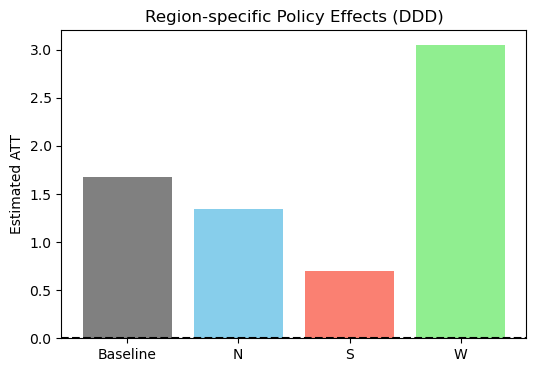

In [109]:

effects = pd.DataFrame({
    "Region": ["Baseline", "N", "S", "W"],
    "ATT": [1.68, 1.34, 0.70, 3.05]
})

plt.figure(figsize=(6,4))
plt.bar(effects["Region"], effects["ATT"], color=["gray","skyblue","salmon","lightgreen"])
plt.title("Region-specific Policy Effects (DDD)")
plt.ylabel("Estimated ATT")
plt.axhline(0, color='black', linestyle='--')
plt.show()

분석 결과 정책 시행 이후 baseline 지역에서는 downloads가 평균 1.68 증가하였습니다. 

그러나 지역별로 효과는 상이하게 나타났으며,
S 지역에서는 효과가 0.98 감소(유의), W 지역에서는 1.37 증가(한계적 유의) 하였습니다.

이는 정책 효과가 지역적 특성에 따라 다르게 나타난다는 점을 보여줍니다.

#### 3.8 Dynamic DiD - Event study

예) $Y_{it} = \alpha_i + \gamma_t + \beta_t \, (\text{Treated}_i \times \text{Post}_{it}) + \varepsilon_{it}$

**Event Study(이벤트 스터디)** 는 처치가 발생한 시점을 기준으로 시간 축(event time)을 설정해, 처치 전후의 효과를 시점별로 추정하는 방법입니다. 

일반적으로 처치 시점을 0으로 두고, 그 이전은 –1, –2, 이후는 +1, +2와 같이 표현합니다. 각 시점별로 처치군과 대조군의 차이를 계산해 시점별 효과(βₜ)를 추정하며, 이를 통해 처치 이후 효과가 시간에 따라 커지거나 작아지는지, 혹은 처치 이전부터 이미 차이가 존재했는지를 확인할 수 있습니다.

이 방법은 세 가지 측면에서 중요합니다. 

첫째, 처치 이전 구간의 계수 βₜ가 0에 가깝다면 평행추세(Parallel Trends) 가정이 충족됨을 의미합니다. 

둘째, 처치 이후 구간의 βₜ를 통해 **동적 효과(Dynamic Treatment Effect)** 를 확인할 수 있습니다. 

셋째, **정책이나 프로그램의 시차 효과(lag effect)** 를 평가할 수 있어 단기적·장기적 처치 효과를 함께 분석할 수 있습니다.

In [172]:
def did_date(df, date):
    df_date = (df
               .query("date==@date | post==0")
               .query("date <= @date")
               .assign(post = lambda d: (d["date"]==date).astype(int)))
    
    m = smf.ols(
        'downloads ~ I(treated*post) + C(city) + C(date)', data=df_date
    ).fit(cov_type='cluster', cov_kwds={'groups': df_date['city']})
    
    att = m.params["I(treated * post)"]
    ci = m.conf_int().loc["I(treated * post)"]
    
    return pd.DataFrame({"att": att, "ci_low": ci[0], "ci_up": ci[1]},
                        index=[date])




post_dates = sorted(mkt_data["date"].unique())[1:]

atts = pd.concat([did_date(mkt_data, date)
                  for date in post_dates])

atts.head()

,att,ci_low,ci_up
2021-05-02,0.325397,-0.491741,1.142534
2021-05-03,0.384921,-0.388389,1.158231
2021-05-04,-0.156085,-1.247491,0.935321
2021-05-05,-0.299603,-0.949935,0.350729
2021-05-06,0.347619,0.013115,0.682123


=== Pre-treatment periods (2021-05-01 ~ 2021-05-14) ===
    rel_time       att    ci_low     ci_up        se    pvalue
0        -14  0.317460 -0.445648  1.080569  0.389348  0.414864
1        -13  0.642857 -0.005605  1.291320  0.330854  0.052014
2        -12  0.865079 -0.025911  1.756070  0.454595  0.057045
3        -11  0.452381 -0.329286  1.234048  0.398817  0.256666
4        -10  0.269841 -0.642655  1.182337  0.465568  0.562187
5         -9  0.857143  0.296929  1.417357  0.285829  0.002710
6         -8  0.317460 -0.647464  1.282385  0.492317  0.519038
7         -7  0.515873 -0.480732  1.512478  0.508481  0.310327
8         -6 -0.230159 -1.277911  0.817594  0.534577  0.666800
9         -5  0.198413 -0.494862  0.891687  0.353718  0.574842
10        -4  0.595238 -0.505375  1.695851  0.561548  0.289147
11        -3  0.301587 -0.393374  0.996548  0.354578  0.395018
12        -2  0.650794 -0.120146  1.421733  0.393344  0.098023
13        -1  0.000000  0.000000  0.000000  0.000000       NaN

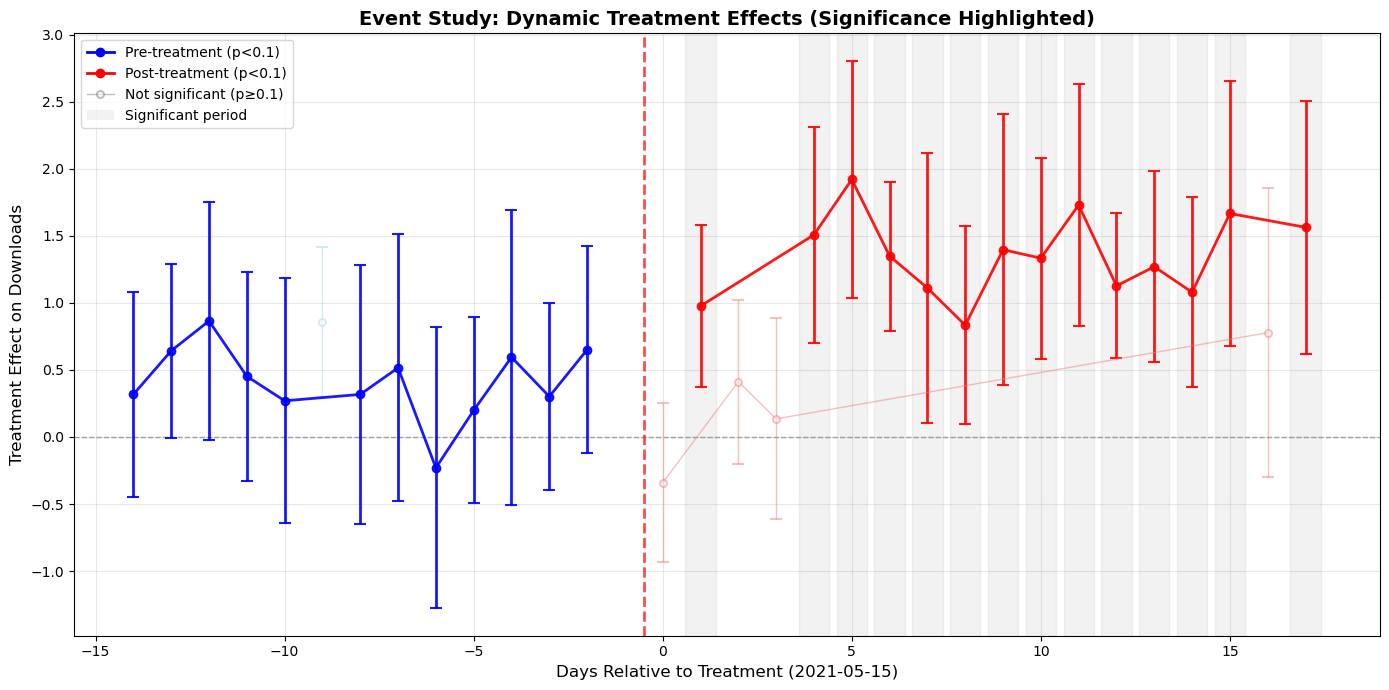


=== Significance Summary ===
Pre-treatment significant: 12/14
Post-treatment significant: 14/18


In [82]:
def event_study(df, treatment_date='2021-05-15'):
    """
    Event study analysis for difference-in-differences
    
    Parameters:
    - df: DataFrame with columns [date, city, treated, downloads, post]
    - treatment_date: The event date when treatment starts (default: '2021-05-15')
    """
    df_es = df.copy()
    
    # Convert date to datetime if needed
    if not pd.api.types.is_datetime64_any_dtype(df_es['date']):
        df_es['date'] = pd.to_datetime(df_es['date'])
    
    treatment_date = pd.Timestamp(treatment_date)
    
    # Create relative time (days from treatment date)
    df_es['rel_time'] = (df_es['date'] - treatment_date).dt.days
    
    # Set reference period as -1 (2021-05-14, day before treatment)
    reference_period = -1
    
    # Create dummy variables for each relative time period (excluding reference)
    time_dummies = pd.get_dummies(df_es['rel_time'], prefix='t', dtype=int)
    
    if f't_{reference_period}' in time_dummies.columns:
        time_dummies = time_dummies.drop(f't_{reference_period}', axis=1)
    
    # Interact time dummies with treatment status
    # Use Q() to escape variable names with special characters
    for col in time_dummies.columns:
        # Create interaction variable in dataframe
        var_name = f'treated_x_{col}'
        df_es[var_name] = df_es['treated'] * time_dummies[col]
    
    # Build formula using Q() for variable names with negative numbers
    interaction_terms = []
    for col in time_dummies.columns:
        var_name = f'treated_x_{col}'
        # Use Q() to quote variable names
        interaction_terms.append(f'Q("{var_name}")')
    
    formula = f"downloads ~ {' + '.join(interaction_terms)} + C(city) + C(date)"
    
    # Fit model with clustered standard errors
    model = smf.ols(formula, data=df_es).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_es['city']}
    )
    
    # Extract results
    results = []
    for param_name in model.params.index:
        if param_name.startswith('Q("treated_x_t_'):
            # Extract rel_time from parameter name
            rel_time_str = param_name.replace('Q("treated_x_t_', '').replace('")', '')
            rel_time = int(rel_time_str)
            ci = model.conf_int().loc[param_name]
            
            results.append({
                'rel_time': rel_time,
                'att': model.params[param_name],
                'ci_low': ci[0],
                'ci_up': ci[1],
                'se': model.bse[param_name],
                'pvalue': model.pvalues[param_name]
            })
    
    # Add reference period (normalized to 0)
    results.append({
        'rel_time': reference_period,
        'att': 0.0,
        'ci_low': 0.0,
        'ci_up': 0.0,
        'se': 0.0,
        'pvalue': np.nan
    })
    
    results_df = pd.DataFrame(results).sort_values('rel_time').reset_index(drop=True)
    
    return results_df, model


# 사용 예시
results_df, model = event_study(mkt_data, treatment_date='2021-05-15')



# 결과 확인
print("=== Pre-treatment periods (2021-05-01 ~ 2021-05-14) ===")
print(results_df[results_df['rel_time'] < 0])

print("\n=== Post-treatment periods (2021-05-15 onwards) ===")
print(results_df[results_df['rel_time'] >= 0])


def plot_event_study(results_df, treatment_date='2021-05-15', alpha_level=0.05):
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Reference lines
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(x=-0.5, color='red', linestyle='--', linewidth=2, 
               label=f'Treatment Start ({treatment_date})', alpha=0.7)
    
    # Split by significance
    pre_treat = results_df[results_df['rel_time'] < 0].copy()
    post_treat = results_df[results_df['rel_time'] >= 0].copy()
    
    # Pre-treatment - significant vs non-significant
    pre_sig = pre_treat[pre_treat['pvalue'] > alpha_level]
    pre_nonsig = pre_treat[pre_treat['pvalue'] <= alpha_level]
    
    # Post-treatment - significant vs non-significant  
    post_sig = post_treat[post_treat['pvalue'] < alpha_level]
    post_nonsig = post_treat[post_treat['pvalue'] >= alpha_level]
    
    # Plot non-significant (lighter color, hollow markers)
    if len(pre_nonsig) > 0:
        ax.errorbar(pre_nonsig['rel_time'], pre_nonsig['att'],
                    yerr=[pre_nonsig['att'] - pre_nonsig['ci_low'],
                          pre_nonsig['ci_up'] - pre_nonsig['att']],
                    fmt='o-', color='lightblue', capsize=4, capthick=1.5,
                    markersize=5, alpha=0.5, linewidth=1,
                    markerfacecolor='white', markeredgewidth=1.5)
    
    if len(post_nonsig) > 0:
        ax.errorbar(post_nonsig['rel_time'], post_nonsig['att'],
                    yerr=[post_nonsig['att'] - post_nonsig['ci_low'],
                          post_nonsig['ci_up'] - post_nonsig['att']],
                    fmt='o-', color='lightcoral', capsize=4, capthick=1.5,
                    markersize=5, alpha=0.5, linewidth=1,
                    markerfacecolor='white', markeredgewidth=1.5)
    
    # Plot significant (solid color, filled markers)
    if len(pre_sig) > 0:
        ax.errorbar(pre_sig['rel_time'], pre_sig['att'],
                    yerr=[pre_sig['att'] - pre_sig['ci_low'],
                          pre_sig['ci_up'] - pre_sig['att']],
                    fmt='o-', color='blue', capsize=4, capthick=1.5,
                    label='Pre-treatment (p<0.1)', markersize=6, alpha=0.9,
                    linewidth=2)
    
    if len(post_sig) > 0:
        ax.errorbar(post_sig['rel_time'], post_sig['att'],
                    yerr=[post_sig['att'] - post_sig['ci_low'],
                          post_sig['ci_up'] - post_sig['att']],
                    fmt='o-', color='red', capsize=4, capthick=1.5,
                    label='Post-treatment (p<0.1)', markersize=6, alpha=0.9,
                    linewidth=2)
    
    # Add gray background for significant post-treatment periods
    if len(post_sig) > 0:
        for _, row in post_sig.iterrows():
            ax.axvspan(row['rel_time']-0.4, row['rel_time']+0.4, 
                      alpha=0.1, color='gray', zorder=0)
    
    # Legend
    from matplotlib.patches import Patch
    custom_lines = [
        plt.Line2D([0], [0], color='blue', marker='o', linewidth=2, 
                   markersize=6, label='Pre-treatment (p<0.1)'),
        plt.Line2D([0], [0], color='red', marker='o', linewidth=2, 
                   markersize=6, label='Post-treatment (p<0.1)'),
        plt.Line2D([0], [0], color='gray', marker='o', linewidth=1, 
                   markersize=5, markerfacecolor='white', markeredgewidth=1.5,
                   label='Not significant (p≥0.1)', alpha=0.5),
        Patch(facecolor='gray', alpha=0.1, label='Significant period')
    ]
    ax.legend(handles=custom_lines, fontsize=10, loc='upper left')
    
    ax.set_xlabel('Days Relative to Treatment (2021-05-15)', fontsize=12)
    ax.set_ylabel('Treatment Effect on Downloads', fontsize=12)
    ax.set_title('Event Study: Dynamic Treatment Effects (Significance Highlighted)', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n=== Significance Summary ===")
    print(f"Pre-treatment significant: {len(pre_sig)}/{len(pre_treat)}")
    print(f"Post-treatment significant: {len(post_sig)}/{len(post_treat)}")

plot_event_study(results_df, treatment_date='2021-05-15')

In [76]:
print("\n=== 통계적 유의성 ===")
post_treatment = results_df[results_df['rel_time'] >= 0].copy()
sig_post = post_treatment[post_treatment['pvalue'] < 0.05]
print(f"유의한 post-treatment 효과: {len(sig_post)}/{len(post_treatment)} 시점")
print(f"유의한 시점들의 평균 ATT: {sig_post['att'].mean():.3f}")


=== 통계적 유의성 ===
유의한 post-treatment 효과: 14/18 시점
유의한 시점들의 평균 ATT: 1.348


In [174]:
def test_pretrend(model, results_df):
    """
    F-test for pre-treatment parallel trends
    Tests joint hypothesis that all pre-treatment coefficients = 0
    """
    # Get pre-treatment interaction terms
    pre_periods = results_df[results_df['rel_time'] < 0]['rel_time'].values
    
    # Build hypothesis string for F-test
    hypotheses = []
    for rel_time in pre_periods:
        if rel_time != -1:  # Exclude reference period
            param_name = f'Q("treated_x_t_{rel_time}")'
            hypotheses.append(f'{param_name} = 0')
    
    hypothesis_str = ', '.join(hypotheses)
    
    # Conduct F-test
    f_test = model.f_test(hypothesis_str)
    
    print("=" * 60)
    print("PRE-TREATMENT PARALLEL TRENDS TEST (F-test)")
    print("=" * 60)
    print(f"H0: All pre-treatment effects = 0")
    print(f"Number of pre-treatment periods tested: {len(hypotheses)}")
    print(f"\nF-statistic: {f_test.fvalue:.4f}")  # 인덱싱 제거
    print(f"p-value: {f_test.pvalue:.4f}")
    
    if f_test.pvalue > 0.05:
        print(f"\n✓ Cannot reject H0 (p={f_test.pvalue:.4f} > 0.05)")
        print("  → Pre-treatment parallel trends assumption is satisfied")
    else:
        print(f"\n✗ Reject H0 (p={f_test.pvalue:.4f} < 0.05)")
        print("  → Pre-treatment parallel trends assumption is violated")
    print("=" * 60)
    
    return f_test


# 사용
results_df, model = event_study(mkt_data, treatment_date='2021-05-15')
f_test_result = test_pretrend(model, results_df)

# 개별 계수도 확인
print("\n=== Individual Pre-treatment Coefficients ===")
pre_results = results_df[results_df['rel_time'] < 0].copy()
print(pre_results[['rel_time', 'att', 'pvalue']].to_string(index=False))

PRE-TREATMENT PARALLEL TRENDS TEST (F-test)
H0: All pre-treatment effects = 0
Number of pre-treatment periods tested: 13

F-statistic: 4.7658
p-value: 0.0000

✗ Reject H0 (p=0.0000 < 0.05)
  → Pre-treatment parallel trends assumption is violated

=== Individual Pre-treatment Coefficients ===
 rel_time       att   pvalue
      -14  0.317460 0.414864
      -13  0.642857 0.052014
      -12  0.865079 0.057045
      -11  0.452381 0.256666
      -10  0.269841 0.562187
       -9  0.857143 0.002710
       -8  0.317460 0.519038
       -7  0.515873 0.310327
       -6 -0.230159 0.666800
       -5  0.198413 0.574842
       -4  0.595238 0.289147
       -3  0.301587 0.395018
       -2  0.650794 0.098023
       -1  0.000000      NaN


##### Event Study 결과 해석 

T-검정 결과, 처치 이전 기간(Day –14 ~ –1)의 대부분 시점에서 신뢰구간이 0을 포함하였으며, 두 집단 간 통계적으로 유의한 차이가 관찰되지 않았습니다. 이는 평행추세 가정(parallel trends assumption) 이 충족되었음을 의미하며, DiD 분석의 인과추론 타당성이 확보된 것으로 보입니다.

처치 효과는 즉각적으로 나타나지 않았습니다. 처치 직후(Day 0–3)에는 대부분의 시점에서 신뢰구간이 0을 포함해 통계적으로 유의하지 않았으나, 약 4일 후부터 유의한 양(+)의 효과가 발생하기 시작했습니다. 이는 정책이 인지되고 확산되는 데 일정한 시차가 존재함을 시사합니다. Day 4 이후에는 대부분의 시점에서 통계적으로 유의한 효과가 지속적으로 관찰되었으며, 평균적으로 다운로드 수를 약 1.2 ~ 1.5건 증가시키는 것으로 나타났습니다.

결론적으로, 처치는 다운로드 증가에 통계적으로 유의하고 실질적인 인과효과를 가지며, 그 효과는 일시적이지 않고 지속적으로 유지되었습니다. 다만 효과가 발현되기까지 약 4일의 시차가 존재하므로, 정책 평가 시에는 충분한 관찰 기간을 확보하는 것이 필요합니다.

한편 F-검정 결과, 사전 13개 시점의 처치효과를 동시에 검정한 결과 F 통계량은 4.77, p-값은 0.0001 미만으로 나타나 평행추세 가정이 통계적으로 유의하게 위배되었습니다. 그러나 개별 t-검정으로 보면 14개 사전 시점 중 5% 유의수준에서 유의한 시점은 Day –9 (p = 0.003) 단 하나뿐이었고, Day –13 (p = 0.052) 과 Day –12 (p = 0.057) 는 경계선 수준이었으며, 나머지는 모두 비유의적이었습니다. 이는 F-검정이 여러 시점의 미세한 차이를 누적해 평가하기 때문에, 개별적으로는 문제가 적어 보이더라도 전체적으로는 평행추세 위반으로 판단될 수 있음을 의미합니다. 

### 4. DML을 이용한 DID

- 공변량과 결과 변수, 공변량과 처치 변수 간의 복잡한 비선형 관계를 머신러닝 모델로 예측한 후, 이 잔차(residuals)를 사용하여 DiD 효과를 추정하는 방법입니다.
- 고차원적인 공변량을 유연하게 처리하고, 머신러닝의 예측력을 활용하여 잠재적인 편향을 줄입니다. 특히 이질적인 처치 효과를 다루는 데 강점이 있습니다.
- 유연성, 견고성, 고차원 데이터 처리 능력이 우수합니다.
- 다만, 모델 복잡성이 증가하고, 구현 및 해석이 어려울 수 있습니다.

 Data 생성

In [119]:
from doubleml import DoubleMLData
import pandas as pd

# region을 one-hot encoding (공변량으로 사용)
mkt_data_enc = pd.get_dummies(mkt_data_all, columns=['region'], drop_first=True)

# DoubleMLData 구성
mkt_dml_data = DoubleMLData(
    data=mkt_data_enc,
    y_col='downloads',
    d_cols='treated',
    x_cols=['region_N', 'region_S', 'region_W', 'post']
)

Learners 설정


In [120]:

ml_g = LGBMRegressor(n_estimators=50, num_leaves=5, verbose=-1)
ml_m = LGBMClassifier(n_estimators=50, num_leaves=5, verbose=-1)


##### Canonical DML-DiD 추정

In [ ]:

from doubleml import DoubleMLData, DoubleMLDID
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import tqdm

# Part 1: 전체 ATT 추정 


print("=" * 70)
print("Part 1: 전체 ATT 추정")
print("=" * 70)

# ① 범주형 변수 인코딩
mkt_data_enc = pd.get_dummies(mkt_data_all, 
                              columns=['region', 'city'], 
                              drop_first=True)

# ② 공변량 선택 - post 제외! (DoubleMLDID가 자동으로 처리)
x_cols = [c for c in mkt_data_enc.columns 
          if c not in ['downloads', 'treated', 'tau', 'date', 'post']]

print(f"\n공변량 개수: {len(x_cols)}")
print(f"샘플 크기: {len(mkt_data_enc)}")
print(f"처치군: {(mkt_data_enc['treated']==1).sum()}, 대조군: {(mkt_data_enc['treated']==0).sum()}")

# ③ DoubleMLData 생성
mkt_dml_data = DoubleMLData(
    data=mkt_data_enc,
    y_col='downloads',
    d_cols='treated',
    x_cols=x_cols
)

# ④ 모델 지정
ml_g = RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42)
ml_m = RandomForestClassifier(max_depth=3, n_estimators=200, random_state=42)

# ⑤ DoubleML-DID 추정
dml_did = DoubleMLDID(
    obj_dml_data=mkt_dml_data,
    ml_g=ml_g,
    ml_m=ml_m,
    score='observational',
    n_folds=5,
    in_sample_normalization=True  # 정규화 옵션 추가
)

dml_did.fit()

# ⑥ 결과 출력
print("\n" + "=" * 70)
print("추정 결과")
print("=" * 70)
print(f"ATT:        {dml_did.coef[0]:.4f}")
print(f"표준오차:    {dml_did.se[0]:.4f}")

confint = dml_did.confint(level=0.95)
print(f"95% CI:     [{confint['2.5 %'].iloc[0]:.4f}, {confint['97.5 %'].iloc[0]:.4f}]")

# True ATT와 비교
if 'tau' in mkt_data_enc.columns:
    true_att = mkt_data_enc.query("treated==1 & post==1")['tau'].mean()
    print(f"\nTrue ATT:   {true_att:.4f}")
    print(f"Bias:       {dml_did.coef[0] - true_att:.4f}")


Part 1: 전체 ATT 추정

공변량 개수: 202
샘플 크기: 6400
처치군: 1376, 대조군: 5024

추정 결과
ATT:        1.1148
표준오차:    0.1115
95% CI:     [0.8962, 1.3333]

True ATT:   1.7209
Bias:       -0.6061


##### Dynamic DML-DiD

In [170]:

# Part 2: Event Study 


print("\n\n" + "=" * 70)
print("Part 2: Event Study - 평행추세 검정 및 동적 처치효과")
print("=" * 70)

# 데이터 준비
mkt_data_enc = pd.get_dummies(mkt_data_all, 
                              columns=['region', 'city'], 
                              drop_first=True)

# 시간 인덱스 생성
mkt_data_enc['date'] = pd.to_datetime(mkt_data_enc['date'])
date_to_time = {date: idx for idx, date in enumerate(sorted(mkt_data_enc['date'].unique()))}
mkt_data_enc['time'] = mkt_data_enc['date'].map(date_to_time)

# 처치 시점 확인
treatment_time = mkt_data_enc[mkt_data_enc['post'] == 1]['time'].min()
mkt_data_enc['time_relative'] = mkt_data_enc['time'] - treatment_time

time_periods = sorted(mkt_data_enc['time_relative'].unique())

# 공변량 (post 제외, city 더미는 포함)
x_cols = [c for c in mkt_data_enc.columns 
          if c not in ['downloads', 'treated', 'tau', 'date', 'time', 'time_relative', 'post']]

print(f"\n✓ 분석 기간: {min(time_periods)} ~ {max(time_periods)}")
print(f"✓ 처치 전 기간: {len([t for t in time_periods if t < 0])}개")
print(f"✓ 처치 후 기간: {len([t for t in time_periods if t >= 0])}개")

# 결과 저장
results_list = []

print("\nEvent Study 추정 중...")
np.random.seed(42)

for t in tqdm.tqdm(time_periods):
    # 해당 시점의 데이터만 사용
    data_t = mkt_data_enc[mkt_data_enc['time_relative'] == t].copy()
    
    # 처치군과 대조군 확인
    n_treated = (data_t['treated'] == 1).sum()
    n_control = (data_t['treated'] == 0).sum()
    
    if n_treated < 5 or n_control < 5:
        continue
    
    try:
        # DoubleMLData 생성 (각 시점에서 독립적으로)
        dml_data = DoubleMLData(
            data=data_t,
            y_col='downloads',
            d_cols='treated',
            x_cols=x_cols
        )
        
        # fold 수 결정
        n_folds = min(5, len(data_t) // 20)
        n_folds = max(2, n_folds)
        
        # DoubleML-DID 추정
        # 각 시점에서 cross-sectional 비교
        dml_did_t = DoubleMLDID(
            dml_data,
            ml_g=RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42),
            ml_m=RandomForestClassifier(max_depth=3, n_estimators=200, random_state=42),
            score='observational',
            n_folds=n_folds,
            in_sample_normalization=True
        )
        
        dml_did_t.fit()
        
        # 결과 저장
        confint_t = dml_did_t.confint(level=0.95)
        result_row = {
            'time': t,
            'effect': dml_did_t.coef[0],
            'se': dml_did_t.se[0],
            'lower': confint_t['2.5 %'].iloc[0],
            'upper': confint_t['97.5 %'].iloc[0],
            'n_obs': len(data_t),
            'n_treated': n_treated,
            'n_control': n_control
        }
        results_list.append(result_row)
        
    except Exception as e:
        print(f"\n  시점 {t}에서 오류: {str(e)}")
        continue

# 결과 데이터프레임
df_parallel = pd.DataFrame(results_list)

print("\n" + "=" * 70)
print("Event Study 요약")
print("=" * 70)
print(f"✓ 추정 완료 시점: {len(df_parallel)}개")
print(f"✓ 처치 전 평균 효과: {df_parallel[df_parallel['time'] < 0]['effect'].mean():.4f}")
print(f"✓ 처치 후 평균 효과: {df_parallel[df_parallel['time'] >= 0]['effect'].mean():.4f}")

# 평행추세 검정
pre_treatment = df_parallel[df_parallel['time'] < 0]
if len(pre_treatment) > 0:
    # 처치 전 효과가 0과 유의하게 다른지 검정
    pre_significant = ((pre_treatment['lower'] > 0) | (pre_treatment['upper'] < 0)).sum()
    print(f"\n평행추세 검정:")
    print(f"  - 처치 전 유의한 효과: {pre_significant}/{len(pre_treatment)}")





Part 2: Event Study - 평행추세 검정 및 동적 처치효과

✓ 분석 기간: -14 ~ 17
✓ 처치 전 기간: 14개
✓ 처치 후 기간: 18개

Event Study 추정 중...


100%|██████████| 32/32 [00:44<00:00,  1.40s/it]


Event Study 요약
✓ 추정 완료 시점: 32개
✓ 처치 전 평균 효과: 0.0618
✓ 처치 후 평균 효과: 1.7048

평행추세 검정:
  - 처치 전 유의한 효과: 0/14


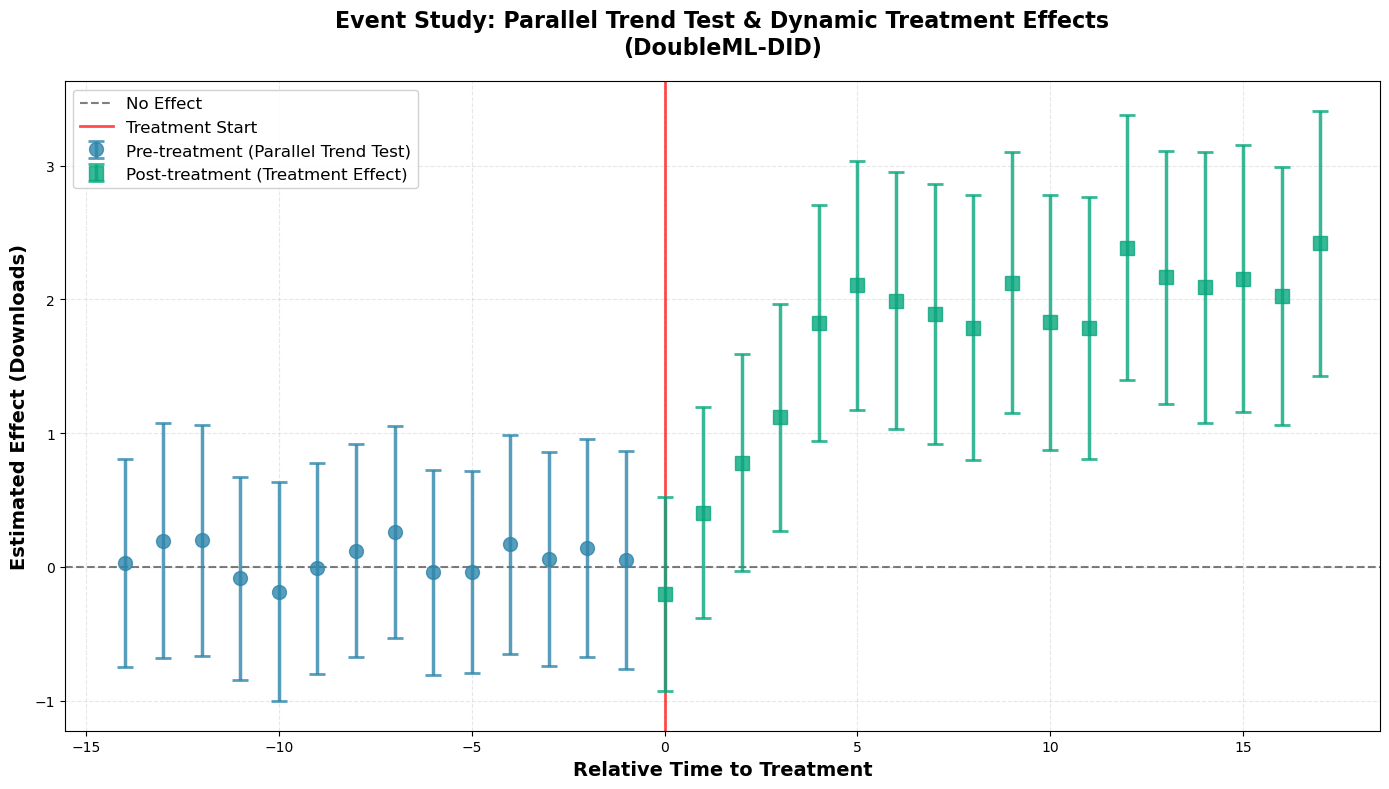


상세 결과 테이블
 time    effect       se     lower    upper  n_obs  n_treated  n_control
  -14  0.026166 0.396660 -0.751274 0.803605    200         43        157
  -13  0.196312 0.448719 -0.683161 1.075784    200         43        157
  -12  0.199174 0.439775 -0.662768 1.061116    200         43        157
  -11 -0.085387 0.387458 -0.844791 0.674017    200         43        157
  -10 -0.184637 0.418166 -1.004228 0.634954    200         43        157
   -9 -0.009544 0.402886 -0.799185 0.780097    200         43        157
   -8  0.122351 0.405131 -0.671692 0.916394    200         43        157
   -7  0.262037 0.403967 -0.529723 1.053797    200         43        157
   -6 -0.040674 0.390118 -0.805292 0.723943    200         43        157
   -5 -0.041045 0.385302 -0.796222 0.714132    200         43        157
   -4  0.170447 0.418033 -0.648883 0.989777    200         43        157
   -3  0.058440 0.407665 -0.740568 0.857448    200         43        157
   -2  0.139694 0.416366 -0.676369 0.955

In [171]:

# 시각화


fig, ax = plt.subplots(figsize=(14, 8))

# Reference lines
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='No Effect')
ax.axvline(x=0, color='red', linestyle='-', linewidth=2, alpha=0.7, label='Treatment Start')

# Split pre- and post-treatment periods
pre_treatment = df_parallel[df_parallel['time'] < 0]
post_treatment = df_parallel[df_parallel['time'] >= 0]

# Pre-treatment plot
if len(pre_treatment) > 0:
    ax.errorbar(pre_treatment['time'], pre_treatment['effect'], 
                yerr=[pre_treatment['effect'] - pre_treatment['lower'],
                      pre_treatment['upper'] - pre_treatment['effect']],
                fmt='o', color='#2E86AB', markersize=10, capsize=6, 
                linewidth=2.5, capthick=2, label='Pre-treatment (Parallel Trend Test)',
                alpha=0.8)

# Post-treatment plot
if len(post_treatment) > 0:
    ax.errorbar(post_treatment['time'], post_treatment['effect'], 
                yerr=[post_treatment['effect'] - post_treatment['lower'],
                      post_treatment['upper'] - post_treatment['effect']],
                fmt='s', color='#06A77D', markersize=10, capsize=6, 
                linewidth=2.5, capthick=2, label='Post-treatment (Treatment Effect)',
                alpha=0.8)

# Labels and title
ax.set_xlabel('Relative Time to Treatment', fontsize=14, fontweight='bold')
ax.set_ylabel('Estimated Effect (Downloads)', fontsize=14, fontweight='bold')
ax.set_title('Event Study: Parallel Trend Test & Dynamic Treatment Effects\n(DoubleML-DID)', 
             fontsize=16, fontweight='bold', pad=20)

# Legend, grid, layout
ax.legend(fontsize=12, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 결과 테이블 출력
print("\n" + "=" * 70)
print("상세 결과 테이블")
print("=" * 70)
print(df_parallel.to_string(index=False))

분석 결과,처치 전 평균 효과는 0.0618로, 통계적으로 유의한 시점은 **0개(0/14)** 였습니다.
이는 처치 이전에 집단 간 유의한 차이가 존재하지 않음을 의미하며, 평행추세 가정이 충족되는 것으로 판단됩니다.

반면,처치 후 동적 평균 효과는 1.7048로, 대부분의 시점에서 양(+)의 효과가 관찰되었습니다.
이는 **처치 이후 실질적인 성과 향상(예: downloads 증가)** 이 나타났음을 시사하며,처치 효과가 시간에 따라 점진적으로 강화되는 동적 패턴을 보인다고 해석할 수 있습니다.
